# EDA & Bottleneck Analysis - Final RAG Benchmark

Notebook này đọc trực tiếp toàn bộ log dùng trong `benchmark_final.md`, chuẩn hóa dữ liệu theo từng câu hỏi, trực quan hóa hiệu năng và phân tích:

- Chất lượng retrieval và chất lượng câu trả lời
- Latency, token usage, route và partial response
- Khác biệt giữa run và nhóm độ khó
- Bottleneck, nguyên nhân khả dĩ, mức độ ưu tiên và hướng cải thiện

**Phạm vi:** 1.005 câu từ Hung (325), Long (250), VinFast Lam (200), HCMUE (170) và VinFast VSF 60 PDF (60). Run VSF 40 PDF không được cộng vì là tập con của run 60 PDF.

> Lưu ý: các run sử dụng relevance/RAGAS backend khác nhau. So sánh chéo run mang tính định hướng; cần benchmark đồng nhất để khẳng định nhân quả.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5.5)

BASE = Path.cwd()
if not (BASE / "per_question_Hung.jsonl").exists():
    candidate = BASE / "evaluation" / "eval_final"
    if candidate.exists():
        BASE = candidate
assert (BASE / "per_question_Hung.jsonl").exists(), f"Không tìm thấy log trong {BASE}"
print("Log directory:", BASE.resolve())

Log directory: E:\TeamHN-RAG-Agent\evaluation\eval_final


## 1. Đọc và chuẩn hóa dữ liệu

In [2]:
RETRIEVAL = ["hit@5", "precision@5", "recall@5", "mrr@5", "map@5", "ndcg@5"]
RAGAS = [
    "ragas_faithfulness", "ragas_answer_relevancy", "ragas_answer_correctness",
    "ragas_semantic_similarity", "ragas_context_precision", "ragas_context_recall",
    "ragas_context_entity_recall", "ragas_noise_sensitivity",
]

def load_nested_jsonl(path, run):
    rows = [json.loads(line) for line in path.open(encoding="utf-8") if line.strip()]
    out = []
    for x in rows:
        q, ret, rag = x["question"], x["retrieval"], x["ragas"]
        out.append({
            "run": run, "qid": q.get("question_id"), "difficulty": q.get("difficulty"),
            "question": q.get("question"), "route": x.get("route"), "partial": x.get("partial"),
            "iterations": x.get("iterations"), "latency_s": x.get("latency"), "total_tokens": x.get("tokens"),
            **{m: ret.get(m) for m in RETRIEVAL},
            **{f"ragas_{k}": rag.get(k) for k in [
                "faithfulness", "answer_relevancy", "answer_correctness", "semantic_similarity",
                "context_precision", "context_recall", "context_entity_recall", "noise_sensitivity"
            ]},
        })
    return pd.DataFrame(out)

def standardize_flat(df, run):
    out = df.copy()
    out["run"] = run
    rename = {"do_kho": "difficulty", "cau_hoi": "question"}
    out = out.rename(columns=rename)
    if "qid" not in out:
        out["qid"] = np.arange(1, len(out) + 1)
    keep = ["run", "qid", "difficulty", "question", "route", "partial", "iterations",
            "latency_s", "total_tokens", *RETRIEVAL, *RAGAS]
    for col in keep:
        if col not in out:
            out[col] = np.nan
    return out[keep]

parts = [
    load_nested_jsonl(BASE / "per_question_Hung.jsonl", "Hung"),
    load_nested_jsonl(BASE / "per_question_Long.jsonl", "Long"),
    standardize_flat(pd.read_csv(BASE / "vinfast_Lam.csv"), "VinFast Lam"),
    standardize_flat(pd.read_excel(BASE / "hcmue_benchmark_review.xlsx"), "HCMUE"),
    standardize_flat(pd.read_json(BASE / "vinfast_benchmark_results_vsf_rag_60pdf.json"), "VinFast VSF 60"),
]
df = pd.concat(parts, ignore_index=True)
df["difficulty"] = df["difficulty"].astype(str).str.strip().str.lower()
df["route"] = df["route"].fillna("unknown").astype(str).str.lower()
df["partial"] = df["partial"].fillna(False).astype(bool)
numeric = ["latency_s", "total_tokens", "iterations", *RETRIEVAL, *RAGAS]
df[numeric] = df[numeric].apply(pd.to_numeric, errors="coerce")
df["answer_quality"] = df[["ragas_answer_correctness", "ragas_answer_relevancy", "ragas_faithfulness"]].mean(axis=1)
df["retrieval_quality"] = df[["hit@5", "recall@5", "mrr@5", "ndcg@5"]].mean(axis=1)
df["token_per_second"] = df["total_tokens"] / df["latency_s"].replace(0, np.nan)

print(f"Tổng số câu: {len(df):,}")
display(df.groupby("run").size().rename("questions").to_frame())

Tổng số câu: 1,005


,questions
run,
HCMUE,170
Hung,325
Long,250
VinFast Lam,200
VinFast VSF 60,60


In [3]:
quality = pd.DataFrame({
    "missing_%": df.isna().mean().mul(100),
    "unique": df.nunique(dropna=True),
}).sort_values("missing_%", ascending=False)
display(quality.head(15).round(2))
assert len(df) == 1005, f"Số câu không như kỳ vọng: {len(df)}"
assert df["qid"].notna().all()

,missing_%,unique
run,0.0,5
qid,0.0,775
difficulty,0.0,12
question,0.0,822
route,0.0,2
partial,0.0,2
iterations,0.0,3
latency_s,0.0,990
total_tokens,0.0,943
hit@5,0.0,2


**Nhận xét chất lượng dữ liệu**

- Tổng số câu được kiểm tra bằng assertion để tránh vô tình cộng trùng hoặc thiếu run.
- Các run không hoàn toàn đồng nhất về backend đánh giá (`llm_proxy` và `heuristic_proxy`) và relevance mode.
- Vì vậy, notebook tập trung mạnh vào xu hướng nội bộ, phân phối và bottleneck; điểm tuyệt đối giữa các run cần được đọc thận trọng.

## 2. Tổng quan KPI theo run

In [4]:
run_summary = df.groupby("run").agg(
    questions=("qid", "size"),
    hit5=("hit@5", "mean"),
    recall5=("recall@5", "mean"),
    mrr5=("mrr@5", "mean"),
    answer_correctness=("ragas_answer_correctness", "mean"),
    faithfulness=("ragas_faithfulness", "mean"),
    avg_latency_s=("latency_s", "mean"),
    p95_latency_s=("latency_s", lambda s: s.quantile(.95)),
    avg_tokens=("total_tokens", "mean"),
    partial_rate=("partial", "mean"),
).sort_values("answer_correctness", ascending=False)
display(run_summary.style.format({
    "hit5": "{:.3f}", "recall5": "{:.3f}", "mrr5": "{:.3f}",
    "answer_correctness": "{:.3f}", "faithfulness": "{:.3f}",
    "avg_latency_s": "{:.2f}", "p95_latency_s": "{:.2f}",
    "avg_tokens": "{:,.1f}", "partial_rate": "{:.1%}",
}))

,questions,hit5,recall5,mrr5,answer_correctness,faithfulness,avg_latency_s,p95_latency_s,avg_tokens,partial_rate
run,,,,,,,,,,
HCMUE,170,0.835,0.609,0.705,0.835,0.922,11.37,28.16,"14,315.5",8.2%
VinFast Lam,200,0.990,0.495,0.980,0.721,0.682,35.01,48.93,"460,769.3",0.0%
Hung,325,0.723,0.618,0.600,0.656,0.772,25.15,95.85,"17,576.9",14.2%
VinFast VSF 60,60,0.883,0.883,0.807,0.624,0.690,3.12,6.85,"1,024.1",0.0%
Long,250,0.460,0.330,0.312,0.362,0.575,38.80,188.31,"15,150.5",22.8%


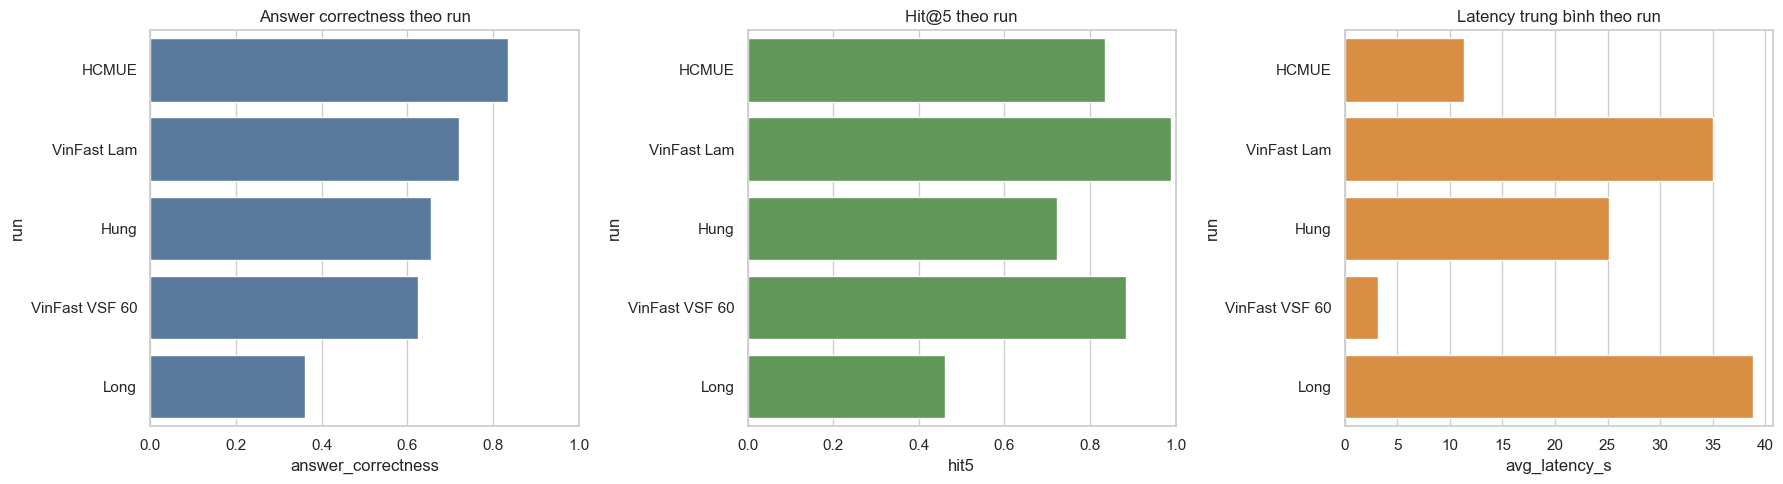

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df = run_summary.reset_index()
sns.barplot(data=plot_df, y="run", x="answer_correctness", ax=axes[0], color="#4C78A8")
axes[0].set_title("Answer correctness theo run"); axes[0].set_xlim(0, 1)
sns.barplot(data=plot_df, y="run", x="hit5", ax=axes[1], color="#59A14F")
axes[1].set_title("Hit@5 theo run"); axes[1].set_xlim(0, 1)
sns.barplot(data=plot_df, y="run", x="avg_latency_s", ax=axes[2], color="#F28E2B")
axes[2].set_title("Latency trung bình theo run")
plt.tight_layout()
plt.show()

### Insight tổng quan

- **HCMUE có chất lượng câu trả lời nổi bật**, đồng thời latency thấp. Đây là run nên dùng làm case study để tìm cấu hình/prompt/retrieval pattern tốt.
- **Long là điểm nghẽn chất lượng rõ nhất**: Hit@5, recall và answer correctness đều thấp. Đây không chỉ là vấn đề generation; retrieval yếu là nguyên nhân nền.
- **VinFast Lam có Hit@5 rất cao nhưng precision@5 thấp theo thiết kế metric**, trong khi token cực lớn. Hit cao không đảm bảo câu trả lời đúng tuyệt đối, đặc biệt với câu cần tổng hợp hoặc hậu xử lý.
- **P95 latency quan trọng hơn average latency** khi đánh giá trải nghiệm người dùng; một số nhóm hard/complex tạo đuôi latency rất dài.

## 3. Phân phối latency và token: tìm tail bottleneck

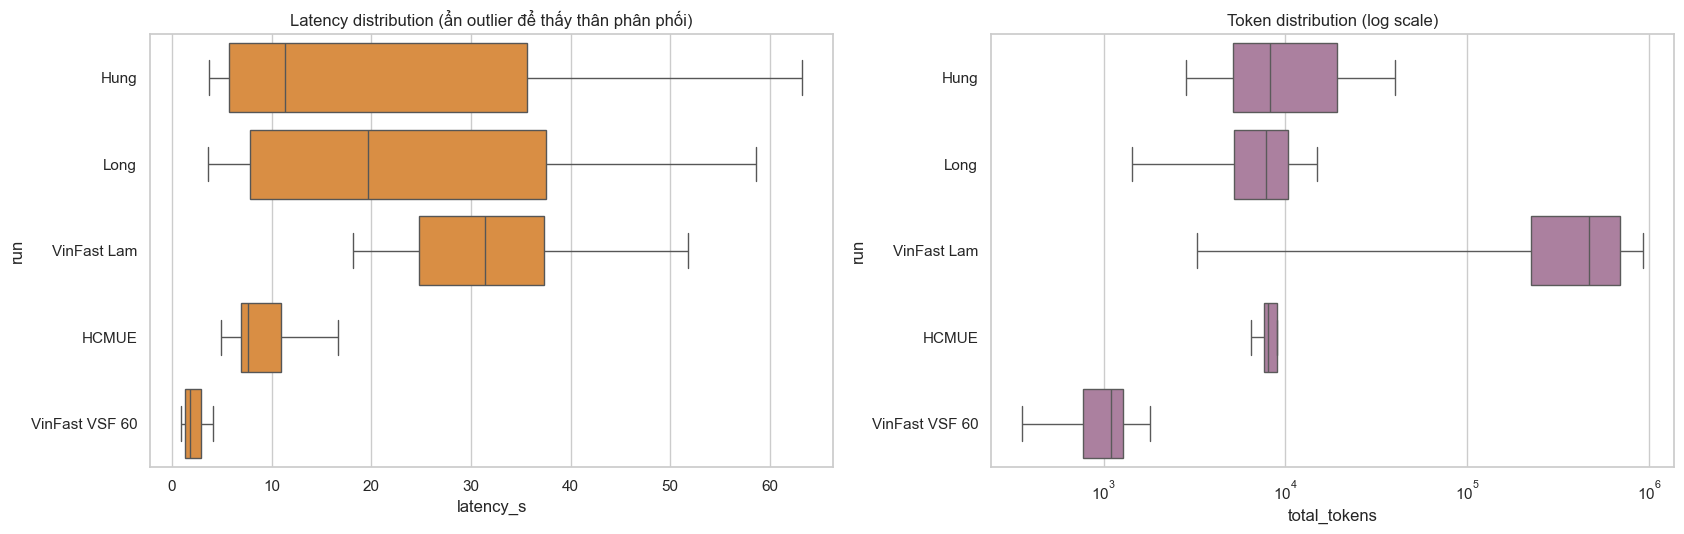

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
sns.boxplot(data=df, x="latency_s", y="run", showfliers=False, ax=axes[0], color="#F28E2B")
axes[0].set_title("Latency distribution (ẩn outlier để thấy thân phân phối)")
sns.boxplot(data=df, x="total_tokens", y="run", showfliers=False, ax=axes[1], color="#B279A2")
axes[1].set_xscale("log")
axes[1].set_title("Token distribution (log scale)")
plt.tight_layout()
plt.show()

In [7]:
tail = df.groupby("run").agg(
    p50_latency=("latency_s", "median"),
    p95_latency=("latency_s", lambda s: s.quantile(.95)),
    p99_latency=("latency_s", lambda s: s.quantile(.99)),
    max_latency=("latency_s", "max"),
    p50_tokens=("total_tokens", "median"),
    p95_tokens=("total_tokens", lambda s: s.quantile(.95)),
    token_latency_corr=("total_tokens", lambda s: s.corr(df.loc[s.index, "latency_s"])),
)
tail["p95_over_p50"] = tail["p95_latency"] / tail["p50_latency"]
display(tail.round(2))

,p50_latency,p95_latency,p99_latency,max_latency,p50_tokens,p95_tokens,token_latency_corr,p95_over_p50
run,,,,,,,,
HCMUE,7.63,28.16,36.08,77.90,7997.0,38137.55,0.94,3.69
Hung,11.30,95.85,162.17,296.14,8184.0,63137.00,0.33,8.48
Long,19.68,188.31,330.27,349.41,7802.0,59169.75,0.59,9.57
VinFast Lam,31.36,48.93,149.00,261.98,465787.5,879633.65,0.08,1.56
VinFast VSF 60,1.78,6.85,25.57,44.03,1095.0,1474.05,-0.02,3.86


### Bottleneck về hiệu năng

1. **Tail latency của câu hard/complex**: average có thể chấp nhận được nhưng P95/P99 cao làm trải nghiệm thiếu ổn định.
2. **Token telemetry của VinFast Lam bất thường**: token trung bình cao hơn nhiều run khác nhưng không tăng tương ứng với latency. Khả năng gồm:
   - Token đang cộng cả context/chunk qua nhiều bước hoặc cộng lặp.
   - Cache/batch/provider usage được ghi nhận khác schema.
   - Trường `total_tokens` không cùng định nghĩa giữa các pipeline.
3. Trước khi tối ưu chi phí từ con số token tổng hợp, cần **chuẩn hóa cách đo token** và log token theo từng LLM call.

## 4. Retrieval có dẫn đến câu trả lời đúng không?

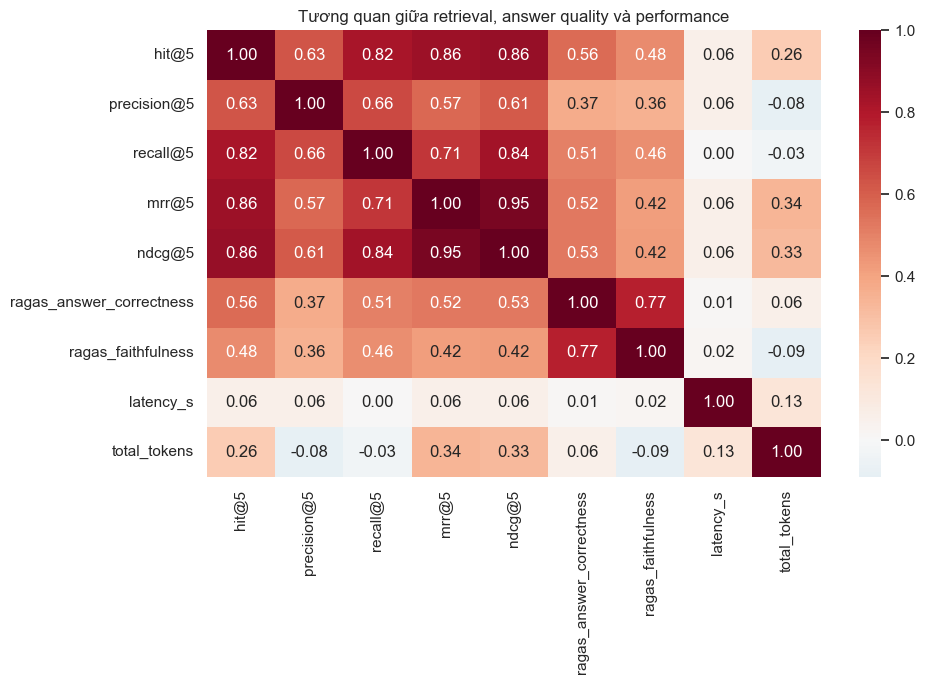

In [8]:
corr_cols = ["hit@5", "precision@5", "recall@5", "mrr@5", "ndcg@5",
             "ragas_answer_correctness", "ragas_faithfulness", "latency_s", "total_tokens"]
corr = df[corr_cols].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Tương quan giữa retrieval, answer quality và performance")
plt.tight_layout()
plt.show()

In [9]:
retrieval_impact = df.assign(hit_group=np.where(df["hit@5"] >= 1, "Hit@5 = 1", "Hit@5 < 1")).groupby("hit_group").agg(
    questions=("qid", "size"),
    answer_correctness=("ragas_answer_correctness", "mean"),
    faithfulness=("ragas_faithfulness", "mean"),
    answer_relevancy=("ragas_answer_relevancy", "mean"),
    latency_s=("latency_s", "mean"),
)
display(retrieval_impact.round(3))

failure_quadrants = pd.crosstab(
    np.where(df["hit@5"] >= 1, "retrieval_hit", "retrieval_miss"),
    np.where(df["ragas_answer_correctness"] >= .7, "answer_good", "answer_weak"),
    margins=True,
)
display(failure_quadrants)

,questions,answer_correctness,faithfulness,answer_relevancy,latency_s
hit_group,,,,,
Hit@5 < 1,262,0.213,0.417,0.334,23.021
Hit@5 = 1,743,0.769,0.835,0.895,28.217


col_0,answer_good,answer_weak,All
row_0,,,
retrieval_hit,547,196,743
retrieval_miss,46,216,262
All,593,412,1005


### Phân rã nguyên nhân lỗi

- **Retrieval miss + answer weak:** ưu tiên sửa index/chunking/query rewrite/reranking.
- **Retrieval hit + answer weak:** context đã có nhưng generation hoặc post-processing chưa khai thác đúng; cần kiểm tra prompt, context ordering, trích dẫn và bước tổng hợp.
- **Retrieval miss + answer good:** có thể metric relevance chưa phản ánh đủ tài liệu tương đương hoặc model dựa vào kiến thức sẵn có. Đây là dấu hiệu cần audit evaluator.
- Tương quan giữa Hit@5 và answer correctness giúp định lượng retrieval là một driver lớn, nhưng không phải driver duy nhất.

## 5. Độ khó, route và partial response

In [10]:
difficulty_summary = df.groupby("difficulty").agg(
    n=("qid", "size"),
    hit5=("hit@5", "mean"),
    correctness=("ragas_answer_correctness", "mean"),
    latency_s=("latency_s", "mean"),
    tokens=("total_tokens", "mean"),
    partial_rate=("partial", "mean"),
).sort_values("correctness")
display(difficulty_summary.style.format({
    "hit5": "{:.3f}", "correctness": "{:.3f}", "latency_s": "{:.2f}",
    "tokens": "{:,.1f}", "partial_rate": "{:.1%}"
}))

,n,hit5,correctness,latency_s,tokens,partial_rate
difficulty,,,,,,
medium,221,0.430,0.399,21.42,"10,805.3",14.0%
easy,219,0.594,0.486,15.75,"5,964.3",16.0%
aggregation,35,0.971,0.584,26.54,"368,249.0",8.6%
false premise,22,1.000,0.627,38.85,"691,759.4",0.0%
simple,106,0.915,0.716,10.97,"66,739.1",0.0%
multi-hop,25,1.000,0.724,45.42,"543,844.4",0.0%
comparison,37,0.919,0.739,23.94,"292,870.0",2.7%
simple w. condition,51,0.941,0.761,18.31,"155,294.1",2.0%
post-processing heavy,87,0.828,0.796,20.33,"143,008.2",8.0%


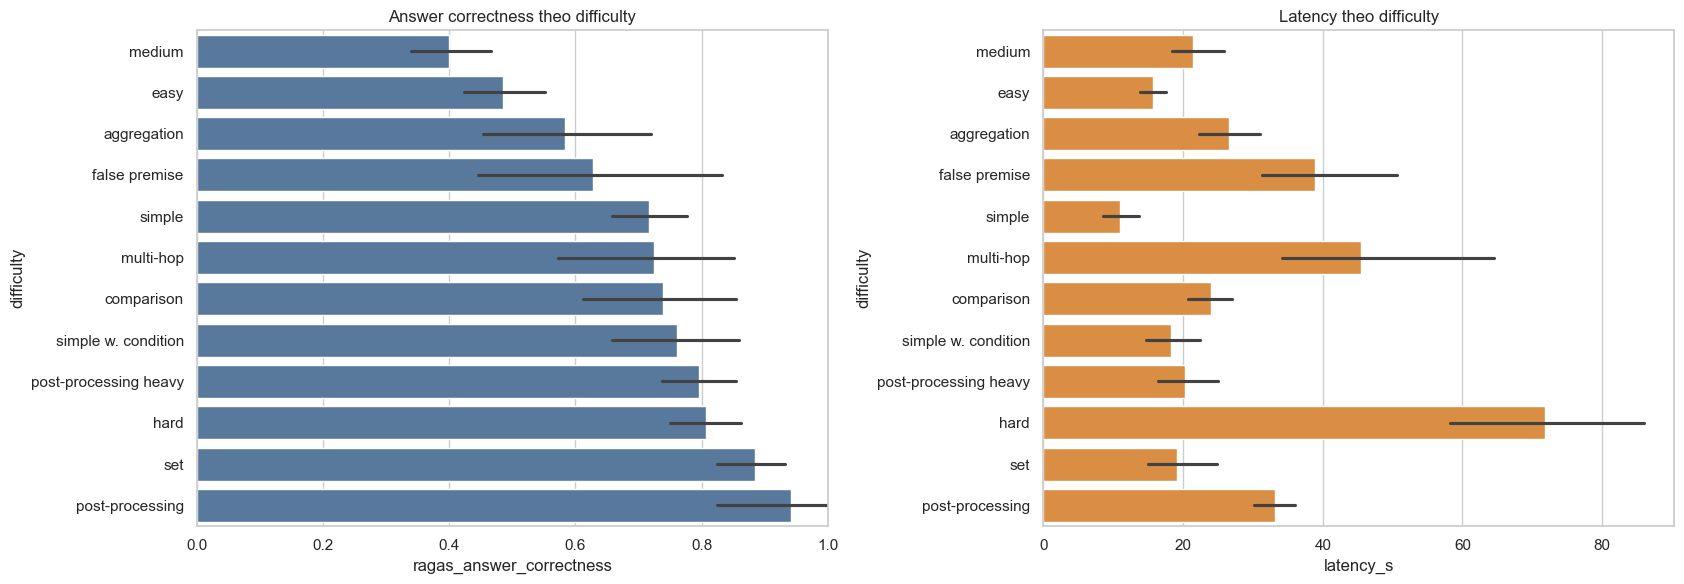

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
order = difficulty_summary.index.tolist()
sns.barplot(data=df, y="difficulty", x="ragas_answer_correctness", order=order, ax=axes[0], color="#4C78A8")
axes[0].set_title("Answer correctness theo difficulty"); axes[0].set_xlim(0, 1)
sns.barplot(data=df, y="difficulty", x="latency_s", order=order, ax=axes[1], color="#F28E2B")
axes[1].set_title("Latency theo difficulty")
plt.tight_layout()
plt.show()

In [12]:
route_summary = df.groupby(["run", "route", "partial"]).agg(
    n=("qid", "size"),
    correctness=("ragas_answer_correctness", "mean"),
    hit5=("hit@5", "mean"),
    latency_s=("latency_s", "mean"),
    tokens=("total_tokens", "mean"),
).reset_index().sort_values(["run", "route", "partial"])
display(route_summary.style.format({
    "correctness": "{:.3f}", "hit5": "{:.3f}", "latency_s": "{:.2f}", "tokens": "{:,.1f}"
}))

,run,route,partial,n,correctness,hit5,latency_s,tokens
0,HCMUE,complex,False,28,0.892,0.893,24.86,"38,585.6"
1,HCMUE,complex,True,6,0.767,0.667,32.18,"43,558.2"
2,HCMUE,simple,False,128,0.838,0.836,7.43,"7,786.1"
3,HCMUE,simple,True,8,0.631,0.750,11.65,"11,908.1"
4,Hung,complex,False,63,0.824,0.905,54.33,"44,790.3"
5,Hung,complex,True,17,0.715,1.000,46.38,"63,998.8"
6,Hung,simple,False,216,0.657,0.704,16.18,"7,106.7"
7,Hung,simple,True,29,0.244,0.310,16.18,"9,230.7"
8,Long,complex,False,38,0.758,0.816,62.60,"41,687.2"
9,Long,complex,True,21,0.738,0.905,182.00,"49,194.5"


### Insight theo độ khó và routing

- Nhóm **medium** có answer correctness thấp nhất dù latency không cao nhất: hệ thống có xu hướng xử lý chưa đủ sâu cho câu không quá rõ ràng nhưng cũng chưa được route sang luồng mạnh.
- Nhóm **hard** đạt correctness khá tốt nhưng đổi lại latency cao. Điều này cho thấy orchestration nhiều bước có hiệu quả, nhưng cần tối ưu chi phí/tail latency.
- Các loại **post-processing heavy, aggregation, comparison** cần được đánh giá riêng vì retrieval hit cao vẫn có thể thất bại ở bước tính toán/tổng hợp.
- Tỷ lệ `partial=True` trong Hung/Long là tín hiệu vận hành quan trọng; cần phân biệt partial do budget, timeout, loop cap hay lỗi downstream.

## 6. Danh sách câu hỏi cần audit ưu tiên

In [13]:
audit = df.assign(
    priority_score=(
        (1 - df["ragas_answer_correctness"].fillna(0)) * 0.45
        + (1 - df["hit@5"].fillna(0)) * 0.30
        + df["latency_s"].rank(pct=True).fillna(0) * 0.15
        + df["partial"].astype(float) * 0.10
    )
).sort_values("priority_score", ascending=False)

cols = ["run", "qid", "difficulty", "route", "partial", "hit@5", "recall@5",
        "ragas_answer_correctness", "latency_s", "total_tokens", "question"]
display(audit[cols].head(25).style.format({
    "hit@5": "{:.2f}", "recall@5": "{:.2f}", "ragas_answer_correctness": "{:.2f}",
    "latency_s": "{:.2f}", "total_tokens": "{:,.0f}"
}))

,run,qid,difficulty,route,partial,hit@5,recall@5,ragas_answer_correctness,latency_s,total_tokens,question
338,Long,DOC003_Q04,medium,simple,True,0.00,0.00,0.00,43.18,"12,451",Cần lưu ý điều kiện hoặc phạm vi nào khi dùng tài liệu để trả lời về giá hoặc điều kiện?
373,Long,DOC010_Q04,medium,simple,True,0.00,0.00,0.00,40.97,"8,610","Nếu người dùng chỉ hỏi “nên chọn/ưu tiên nội dung nào” mà không nói rõ họ quan tâm gói/quyền lợi/thông số, giá hoặc điều kiện hay lựa chọn phù hợp nhu cầu, nên xử lý thế nào?"
22,Hung,2026_293_159_2026_NĐ-CP_Q03,medium,simple,True,0.00,0.00,0.00,38.30,"6,128",Quy định tại Điều 3 của tài liệu nêu nội dung chính nào cần chú ý khi đánh giá RAG?
37,Hung,2026_294_167_2026_NĐ-CP_Q03,medium,simple,True,0.00,0.00,0.00,38.10,"6,127",Quy định tại Điều 3 của tài liệu nêu nội dung chính nào cần chú ý khi đánh giá RAG?
368,Long,DOC009_Q04,medium,simple,True,0.00,0.00,0.00,36.42,"12,457",Cần lưu ý điều kiện hoặc phạm vi nào khi dùng tài liệu để trả lời về giá hoặc điều kiện?
347,Long,DOC005_Q03,medium,simple,True,0.00,0.00,0.00,36.38,"6,901","Khi tra cứu nhanh tài liệu này, nên chú ý những nhóm thông tin nào?"
348,Long,DOC005_Q04,medium,simple,True,0.00,0.00,0.00,35.97,"6,639","Nếu người dùng chỉ hỏi “nên chọn/ưu tiên nội dung nào” mà không nói rõ họ quan tâm khái niệm công nghệ, yêu cầu triển khai hay rủi ro/quản trị, nên xử lý thế nào?"
356,Long,DOC007_Q02,easy,simple,True,0.00,0.00,0.00,35.89,"5,287","Trong ngữ cảnh tài liệu này, nhóm nội dung “bối cảnh xã hội” nên được hiểu là gì?"
32,Hung,2026_293_66.17_2026_NQ-CP_Q03,medium,simple,True,0.00,0.00,0.00,35.62,"6,127",Quy định tại Điều 3 của tài liệu nêu nội dung chính nào cần chú ý khi đánh giá RAG?
57,Hung,2026_294_185_2026_NĐ-CP_Q03,medium,simple,True,0.00,0.00,0.00,35.43,"13,117",Quy định tại Điều 3 của tài liệu nêu nội dung chính nào cần chú ý khi đánh giá RAG?


In [14]:
outliers = df.loc[df["latency_s"] >= df["latency_s"].quantile(.99), cols].sort_values("latency_s", ascending=False)
display(Markdown(f"**Top 1% latency gồm {len(outliers)} câu:**"))
display(outliers.head(20).style.format({"latency_s": "{:.2f}", "total_tokens": "{:,.0f}"}))

**Top 1% latency gồm 11 câu:**

,run,qid,difficulty,route,partial,hit@5,recall@5,ragas_answer_correctness,latency_s,total_tokens,question
389,Long,DOC013_Q05,hard,complex,True,1.000000,0.333333,1.000000,349.41,"78,328","Để trả lời một câu hỏi tổng hợp về VITRANSS 3 - Chiến lược phát triển giao thông vận tải bền vững, cần kết nối những lớp thông tin nào trong tài liệu?"
328,Long,DOC001_Q04,medium,complex,True,0.000000,0.000000,0.500000,344.57,"70,733",Cần lưu ý điều kiện hoặc phạm vi nào khi dùng tài liệu để trả lời về giá hoặc điều kiện?
329,Long,DOC001_Q05,hard,complex,True,1.000000,1.000000,1.000000,334.68,"73,665","Để trả lời một câu hỏi tổng hợp về VinFast VF 3 brochure, cần kết nối những lớp thông tin nào trong tài liệu?"
374,Long,DOC010_Q05,hard,complex,True,1.000000,0.500000,1.000000,325.68,"35,268","Để trả lời một câu hỏi tổng hợp về VinFast VF e34 brochure, cần kết nối những lớp thông tin nào trong tài liệu?"
339,Long,DOC003_Q05,hard,complex,True,1.000000,1.000000,1.000000,318.07,"32,757","Để trả lời một câu hỏi tổng hợp về VinFast VF 5 brochure, cần kết nối những lớp thông tin nào trong tài liệu?"
404,Long,DOC016_Q05,hard,complex,True,1.000000,1.000000,0.000000,301.94,"41,121","Để trả lời một câu hỏi tổng hợp về Báo cáo chuyển đổi số quốc gia 2023, cần kết nối những lớp thông tin nào trong tài liệu?"
369,Long,DOC009_Q05,hard,complex,True,1.000000,0.500000,0.000000,298.80,"53,198","Để trả lời một câu hỏi tổng hợp về VinFast VF 9 brochure, cần kết nối những lớp thông tin nào trong tài liệu?"
34,Hung,2026_293_66.17_2026_NQ-CP_Q05,hard,complex,False,1.000000,1.000000,1.000000,296.14,"41,796","Khi một thủ tục/điều kiện kinh doanh đã được cắt giảm hoặc phân quyền nhưng hồ sơ đã nộp trước ngày văn bản có hiệu lực, hệ thống RAG cần xử lý câu trả lời theo logic nào?"
364,Long,DOC008_Q05,hard,complex,False,0.000000,0.000000,0.000000,264.67,"32,291","Để trả lời một câu hỏi tổng hợp về Hướng dẫn sử dụng thiết bị y tế, cần kết nối những lớp thông tin nào trong tài liệu?"
414,Long,DOC018_Q05,hard,complex,True,1.000000,0.400000,1.000000,263.44,"47,845","Để trả lời một câu hỏi tổng hợp về Thông tư 02/2024 về lao động nước ngoài, cần kết nối những lớp thông tin nào trong tài liệu?"


## 7. Kết luận, nguyên nhân và hướng cải thiện

### Chẩn đoán chính

| Mức ưu tiên | Bottleneck | Dấu hiệu trong log | Nguyên nhân khả dĩ |
|---|---|---|---|
| P0 | Chất lượng run Long thấp | Retrieval và answer correctness cùng thấp | Corpus/index mismatch, chunking, query rewrite hoặc relevance judge |
| P0 | Telemetry token không đồng nhất | VinFast Lam có token cực cao nhưng tương quan latency thấp | Khác định nghĩa token, cộng lặp usage hoặc log nhiều bước không chuẩn |
| P1 | Nhóm medium bị xử lý thiếu sâu | Correctness thấp nhưng latency thấp hơn hard rõ rệt | Router chưa nhận diện độ phức tạp, budget/iterations chưa phù hợp |
| P1 | Retrieval hit nhưng answer vẫn yếu | Có nhiều câu hit nhưng correctness dưới ngưỡng | Context ordering, prompt tổng hợp, post-processing hoặc citation grounding |
| P1 | Tail latency cao | P95/P99 cách xa median ở một số run/nhóm | Nhiều vòng lặp, context lớn, retry, tool/LLM call nối tiếp |
| P2 | Partial response | Xuất hiện chủ yếu trong Hung/Long | Timeout, iteration cap, token budget hoặc lỗi orchestration |

### Hướng cải thiện đề xuất

1. **Chuẩn hóa benchmark và telemetry trước**
   - Một schema chung cho `prompt_tokens`, `completion_tokens`, `total_tokens`, `llm_calls`, latency từng stage.
   - Ghi rõ evaluator backend/relevance mode theo từng câu.
   - Thêm `trace_id`, thời gian retrieval/rerank/generation/post-processing.

2. **Tập trung sửa retrieval cho Long và nhóm medium**
   - Audit 25 câu ưu tiên ở trên, phân loại lỗi: missing document, bad chunk, bad query, bad rank.
   - Thử hybrid retrieval + reranker; đo Recall@20 trước rerank và NDCG@5 sau rerank.
   - Điều chỉnh chunk size/overlap theo loại tài liệu thay vì dùng một cấu hình chung.

3. **Cải thiện router và budget thích ứng**
   - Route theo tín hiệu ambiguity, số thực thể, aggregation/comparison intent và retrieval confidence.
   - Nếu confidence thấp hoặc câu medium có nhiều thực thể, nâng budget/iterations hoặc kích hoạt query decomposition.
   - Đặt early-stop khi đủ bằng chứng để giảm tail latency của hard.

4. **Sửa generation khi retrieval đã hit**
   - Bắt buộc answer dựa trên evidence, sắp xếp context theo relevance và loại duplicate chunk.
   - Tách prompt cho aggregation/comparison/post-processing; bổ sung bước kiểm tra kết quả.
   - Với câu số liệu, dùng structured extraction/calculator thay vì chỉ sinh tự do.

5. **Mục tiêu cho vòng benchmark tiếp theo**
   - Long: tăng Hit@5 và answer correctness tối thiểu 10 điểm phần trăm.
   - Giảm P95 latency ít nhất 20% mà không giảm correctness.
   - Partial rate dưới 2%.
   - Xác minh và giảm token/câu sau khi chuẩn hóa telemetry.

### Thiết kế thí nghiệm khuyến nghị

- Giữ nguyên một tập câu cố định và evaluator thống nhất.
- Chạy A/B từng thay đổi độc lập: baseline, reranker, adaptive router, prompt theo intent.
- Báo cáo confidence interval/bootstrap thay vì chỉ dùng trung bình.
- Theo dõi cả quality, P50/P95 latency, token/câu và chi phí/câu đúng.

In [15]:
# Bảng baseline gọn để dùng làm mốc cho lần cải thiện tiếp theo
baseline = run_summary[["questions", "hit5", "recall5", "answer_correctness", "avg_latency_s", "p95_latency_s", "avg_tokens", "partial_rate"]]
display(baseline.round(4))

,questions,hit5,recall5,answer_correctness,avg_latency_s,p95_latency_s,avg_tokens,partial_rate
run,,,,,,,,
HCMUE,170,0.8353,0.6093,0.8350,11.3699,28.1596,14315.5176,0.0824
VinFast Lam,200,0.9900,0.4950,0.7210,35.0100,48.9345,460769.3050,0.0000
Hung,325,0.7231,0.6184,0.6557,25.1525,95.8502,17576.9200,0.1415
VinFast VSF 60,60,0.8833,0.8833,0.6239,3.1210,6.8498,1024.1000,0.0000
Long,250,0.4600,0.3300,0.3620,38.8008,188.3146,15150.4640,0.2280
